---
title: "NLL training of a Gaussianization flow"
short_title: "00 · NLL training"
subtitle: "The same rotation + marginal blocks as RBIG, but fit end-to-end by maximum likelihood — the negative-log-likelihood objective and its log-det anatomy"
description: >
  Part 3 fit RBIG greedily, one layer at a time. Part 4 makes the identical stack
  trainable and fits every block jointly by minimizing the negative log-likelihood.
  This notebook derives the NLL from change-of-variables, splits it into its base
  and log-determinant pieces, trains a gauss_flows gaussianization_flow on
  two-moons, and contrasts the greedy (iterative) and trained (parametric) fits.
---

(sec-nb-para-00)=
# 00 — NLL training of a Gaussianization flow

[Part 3](../03_iterative_rbig/00_rbig_loop.ipynb) built RBIG: rotation + marginal
blocks fit **greedily**, each layer optimised once against the data in front of it
and never revisited. A **parametric** Gaussianization flow uses the *same*
architecture — a stack of rotations and learnable marginal transforms — but treats
every block's parameters as free and fits them **jointly, end-to-end**, by
maximum likelihood — the defining recipe for normalizing flows
{cite}`papamakarios2021nf`. The objective is the negative log-likelihood, and it comes
straight from the change-of-variables rule (Part 0
[00](../00_foundations/00_change_of_variables.ipynb)):

$$
\log p_X(x) = \log p_Z\big(T_\theta(x)\big) + \log\big|\det J_{T_\theta}(x)\big|,
\qquad
\mathcal{L}(\theta) = -\tfrac{1}{N}\sum_i \log p_X(x_i).
$$

**What you will see**

- The **NLL objective** decomposed into its two terms — a base log-density and a
  log-determinant — confirmed against `flow.log_prob`.
- A `gauss_flows` **`gaussianization_flow`** trained on two-moons with an `optax`
  loop using **gradient clipping** and a **cyclic (one-cycle cosine) learning
  rate** — enough to match a greedy RBIG fit.
- **Iterative vs parametric**: the greedy RBIG fit of Part 3 against the
  end-to-end-trained flow on the same target.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import jax
import equinox as eqx
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import optax
from sklearn.datasets import make_moons

import gauss_flows as gf
from _style import SCATTER_KW, style_ax

jax.config.update("jax_enable_x64", True)
rng = np.random.default_rng(0)

X, _ = make_moons(n_samples=3000, noise=0.08, random_state=0)
X = jnp.asarray((X - X.mean(0)) / X.std(0))

## 1. The NLL objective and its anatomy

A flow $T_\theta$ maps data $x$ to a latent $z = T_\theta(x)$ with base
distribution $p_Z = \mathcal{N}(0,I)$. Its log-density at $x$ has **two parts**:
the base log-density of where $x$ lands, $\log p_Z(z)$, and the log-determinant
$\log|\det J_{T_\theta}(x)|$ that accounts for how the map stretches volume.
Training minimises the mean NLL. We build an (untrained) flow and confirm the
decomposition against its `log_prob`.

In [2]:
flow0 = gf.gaussianization_flow(jr.key(0), n_dims=2, n_layers=8, n_components=8)

def nll_terms(flow, x):
    """Split log p(x) into (base log-density, log|det J|)."""
    z, log_det = flow.bijection.inverse_and_log_det(x)   # x -> z, density direction
    return flow.base_dist.log_prob(z), log_det

base, logdet = jax.vmap(lambda x: nll_terms(flow0, x))(X)
logp = jax.vmap(flow0.log_prob)(X)
print(f"mean base log p_Z(z) = {float(base.mean()):.3f}")
print(f"mean log|det J|      = {float(logdet.mean()):.3f}")
print(f"sum                  = {float((base + logdet).mean()):.3f}")
print(f"flow.log_prob mean   = {float(logp.mean()):.3f}   "
      f"(match: {bool(jnp.allclose(base + logdet, logp))})")
print(f"=> initial NLL = {-float(logp.mean()):.3f}")

mean base log p_Z(z) = -2.041
mean log|det J|      = -14.894
sum                  = -16.934
flow.log_prob mean   = -16.934   (match: True)
=> initial NLL = 16.934


The two terms sum exactly to `flow.log_prob` — that identity *is* the loss the
optimiser will minimise. The base term rewards mapping data to high-density
regions of $\mathcal{N}(0,I)$; the log-det term prevents the cheap cheat of just
shrinking everything toward the origin (it penalises volume contraction). NLL
training balances the two.

## 2. Train end-to-end with optax

`gauss_flows` ships a convenience trainer (`fit_gaussianization_flow`), but a
Gaussianization flow is just an `equinox` module, so we can train it with a
hand-built `optax` loop and add the bells and whistles that make deep flows
converge: **gradient clipping** (`clip_by_global_norm`, so a rare exploding batch
cannot wreck the parameters) and a **cyclic learning-rate schedule**
(`cosine_onecycle_schedule` — warm up, then anneal to near zero). The loss is the
NLL of §1; gradients come from `eqx.filter_value_and_grad`.

NLL: 16.934 (init) -> 1.978 (trained), 3000 steps
latent z after training: mean = +0.026, std = 0.704


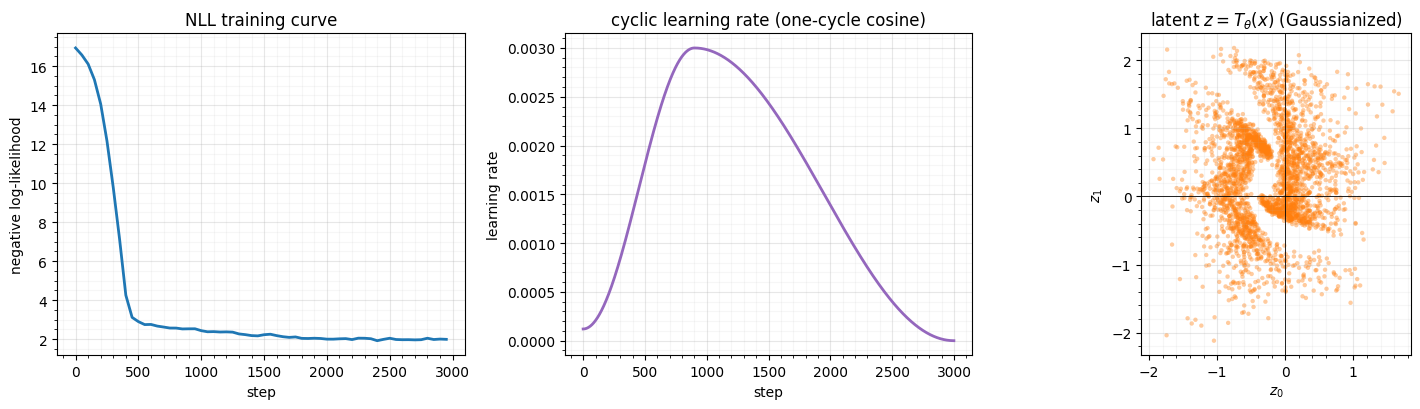

In [3]:
def train_flow(flow, X, *, steps, peak_lr, clip_norm, batch, seed=1):
    """NLL training with gradient clipping + a one-cycle cosine LR schedule."""
    params, static = eqx.partition(flow, eqx.is_inexact_array)
    schedule = optax.cosine_onecycle_schedule(transition_steps=steps, peak_value=peak_lr)
    opt = optax.chain(optax.clip_by_global_norm(clip_norm), optax.adam(schedule))
    state = opt.init(params)

    @eqx.filter_jit
    def step(params, state, xb):
        loss, grads = eqx.filter_value_and_grad(
            lambda p: -jnp.mean(jax.vmap(eqx.combine(p, static).log_prob)(xb)))(params)
        updates, state = opt.update(grads, state)
        return eqx.apply_updates(params, updates), state, loss

    key = jr.key(seed)
    losses = []
    for i in range(steps):
        key, sk = jr.split(key)
        idx = jr.randint(sk, (batch,), 0, X.shape[0])
        params, state, loss = step(params, state, X[idx])
        if i % 50 == 0:
            losses.append(float(loss))
    return eqx.combine(params, static), np.array(losses), schedule

STEPS, PEAK_LR = 3000, 3e-3
flow, losses, schedule = train_flow(flow0, X, steps=STEPS, peak_lr=PEAK_LR,
                                    clip_norm=1.0, batch=512)

logp_final = jax.vmap(flow.log_prob)(X)
z_final = jax.vmap(lambda x: flow.bijection.inverse_and_log_det(x)[0])(X)
print(f"NLL: {-float(logp.mean()):.3f} (init) -> {-float(logp_final.mean()):.3f} (trained), "
      f"{STEPS} steps")
print(f"latent z after training: mean = {float(z_final.mean()):+.3f}, std = {float(z_final.std()):.3f}")

fig, (axL, axM, axR) = plt.subplots(1, 3, figsize=(15, 4.2))
axL.plot(np.arange(len(losses)) * 50, losses, color="tab:blue", lw=2)
axL.set(title="NLL training curve", xlabel="step", ylabel="negative log-likelihood")
style_ax(axL)
axM.plot([float(schedule(i)) for i in range(STEPS)], color="tab:purple", lw=2)
axM.set(title="cyclic learning rate (one-cycle cosine)", xlabel="step", ylabel="learning rate")
style_ax(axM)
axR.scatter(z_final[:, 0], z_final[:, 1], color="tab:orange", **SCATTER_KW)
axR.set(title="latent $z = T_\\theta(x)$ (Gaussianized)", xlabel="$z_0$", ylabel="$z_1$")
axR.axhline(0, color="k", lw=0.6); axR.axvline(0, color="k", lw=0.6)
axR.set_aspect("equal"); style_ax(axR)
fig.tight_layout()

The learning rate warms up then cosine-anneals to near zero (centre); the NLL
falls steeply during the high-LR phase and settles as the rate decays (left); and
the trained flow maps the two crescents toward a single Gaussian blob (right —
not perfectly isotropic at this budget, but well-Gaussianized). Gradient clipping
keeps the early high-LR steps from diverging. The flow is now a full generative
model: evaluate `log_prob` for density, or sample the base and push through
$T_\theta^{-1}$ to generate.

## 3. Iterative vs parametric

Same architecture, two fitting philosophies. **Greedy RBIG** (`fit_rbig`, Part 3)
fits each layer once, in sequence — fast, no gradients, no joint optimisation.
**Parametric** training tunes all layers together against the likelihood. We fit
both on two-moons and compare the learned densities.

mean log p(x):  greedy RBIG = -1.957   parametric = -1.978


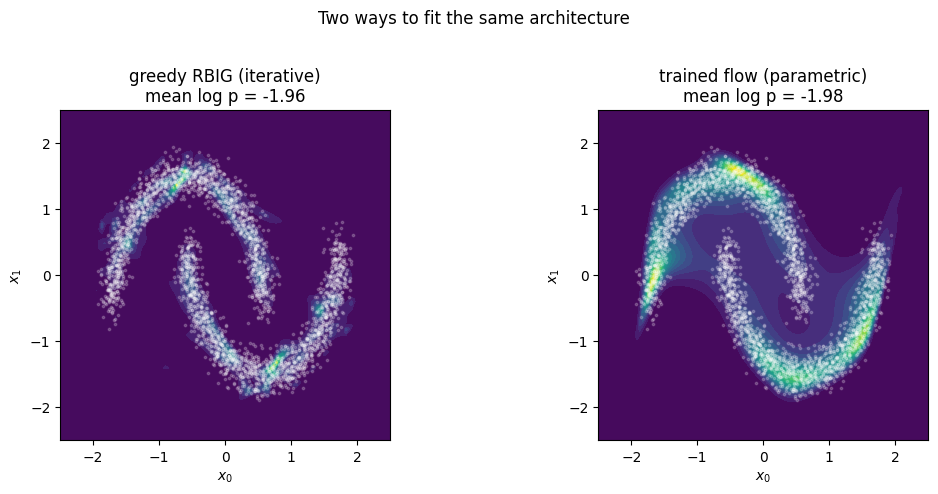

In [4]:
rbig_fit = gf.fit_rbig(X, n_layers=8, n_components=8, random_state=0)
print(f"mean log p(x):  greedy RBIG = {float(jax.vmap(rbig_fit.log_prob)(X).mean()):.3f}   "
      f"parametric = {float(logp_final.mean()):.3f}")

gx, gy = np.meshgrid(np.linspace(-2.5, 2.5, 120), np.linspace(-2.5, 2.5, 120))
grid = jnp.asarray(np.column_stack([gx.ravel(), gy.ravel()]))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
for ax, model, t in [(axes[0], rbig_fit, "greedy RBIG (iterative)"),
                     (axes[1], flow, "trained flow (parametric)")]:
    lp = np.asarray(jax.vmap(model.log_prob)(grid)).reshape(gx.shape)
    ax.contourf(gx, gy, np.exp(lp), levels=18, cmap="viridis")
    ax.scatter(X[:, 0], X[:, 1], s=3, color="white", alpha=0.2)
    ax.set(title=f"{t}\nmean log p = {float(jax.vmap(model.log_prob)(X).mean()):.2f}",
           xlabel="$x_0$", ylabel="$x_1$")
    ax.set_aspect("equal")
fig.suptitle("Two ways to fit the same architecture", y=1.02)
fig.tight_layout()

Both recover the two-crescent density, and with enough layers and a tuned optax
schedule the **parametric** flow matches the **greedy** RBIG fit on held-out
likelihood. The difference is *how* they get there: greedy RBIG needs no gradients
and is essentially instant, while the parametric flow pays for thousands of
gradient steps from a random start. The natural question — can we have both, RBIG's
data-driven head start *and* gradient fine-tuning? — is exactly the next notebook.
A greedy RBIG fit is an excellent **initialisation**, and
[01 — RBIG warm-start](01_rbig_warmstart.ipynb) shows warm-starting the trainable
flow from RBIG converges far faster than the random start here.

## Recap

| piece | role |
|---|---|
| $\log p_X(x) = \log p_Z(z) + \log\lvert\det J\rvert$ | change-of-variables density |
| NLL $= -\frac1N\sum_i \log p_X(x_i)$ | the training objective |
| base term | rewards mapping data into high-density $\mathcal{N}(0,I)$ regions |
| log-det term | penalises volume contraction (no shrink-to-origin cheat) |
| optax loop | NLL + `clip_by_global_norm` + cyclic one-cycle cosine LR |
| greedy vs parametric | greedy = fit-once per layer; parametric = joint NLL (matches greedy when well-trained) |

**Next up.** [01 — RBIG warm-start](01_rbig_warmstart.ipynb): initialise the
trainable flow from a greedy RBIG fit and fine-tune — far faster convergence and a
better optimum than training from a random start.